# Cardinal sim quick look

In [4]:
#import tables_io
import pandas as pd
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import matplotlib
import os

In [12]:
# truth catalogue (rotated)
INPUT_DIR = "/global/cfs/cdirs/lsst/groups/PZ/Cardinal/parquet_files/dp2_mock_run_cardinal_gold/" 
pixels = os.listdir(INPUT_DIR)

In [13]:
# let's load the truth catalogue, the degraded catalogue, and the DESI selection
# let's get the galaxy number count map:
root = "/global/cfs/cdirs/lsst/groups/PZ/Cardinal/parquet_files/dp2_mock_run_cardinal_gold_test/"
N_counts = 0
for i, pix in enumerate(pixels):
    if i%20 == 0:
        print(f"working on {i}/{len(pixels)}")
    fname = root + f"{pix}/output_deredden_lsst_obs_cond_dp2_select_v0.pq"
    df = pd.read_parquet(fname)
    df_pix = hp.ang2pix(256, df['ra'], df['dec'], lonlat=True)
    counts = np.bincount(df_pix, minlength = int(12*256**2))
    N_counts += counts

working on 0/54
working on 20/54
working on 40/54


In [121]:
# load the depth mask:
nvisits = {}
depth = {}
for b in "ugrizy":
    nvisits[b] = hp.read_map(f'/global/cfs/cdirs/lsst/groups/PZ/users/qhang/dp2_maps_may/dp2_public_catalog_n_visits_{b}_nside-256.fits')
    depth[b] = hp.read_map(f'/global/cfs/cdirs/lsst/groups/PZ/users/qhang/dp2_maps_may/dp2_public_catalog_m5_ps_{b}_nside-256.fits')

In [18]:
mask = hp.read_map('/global/cfs/cdirs/lsst/groups/PZ/users/qhang/dp2_maps_may/dp2_public_catalog_mask_nside-256.fits')

In [19]:
def get_boundary_pixels(mask):
    masked_pixels = np.where(mask == 1)[0]
    boundary = []
    for pix in masked_pixels:
        neighbours = hp.get_all_neighbours(hp.get_nside(mask), pix)
        # If any neighbour is outside the mask (or invalid=-1), it's a boundary pixel
        if np.any(mask[neighbours[neighbours >= 0]] == 0):
            boundary.append(pix)
    return np.array(boundary)

In [21]:
boundary_pixels = get_boundary_pixels(mask)
boundary_theta, boundary_phi = hp.pix2ang(256, boundary_pixels, lonlat=True)

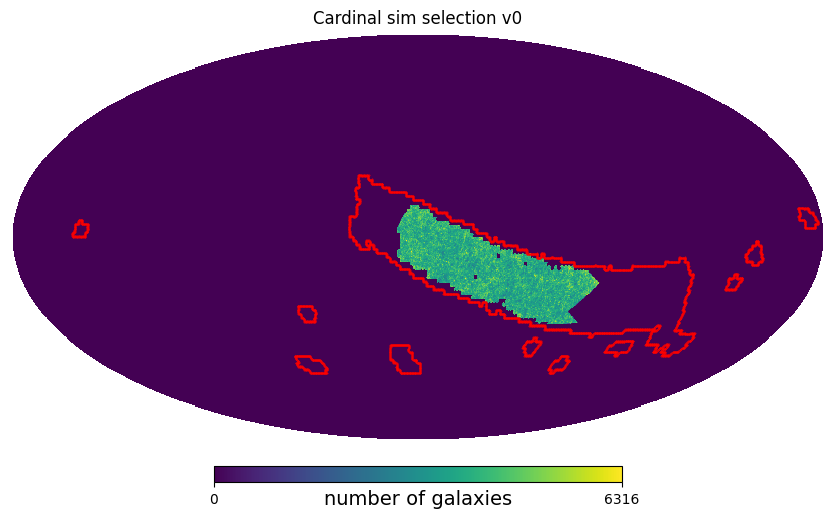

In [24]:
hp.mollview(N_counts, unit="number of galaxies", title="Cardinal sim selection v0")
hp.projscatter(boundary_theta, boundary_phi, lonlat=True,
               s=0.5, c="red", marker=".", label="master mask")
if(0):
    hp.write_map("cardinal_dp2_mock_ngal_select_v0.fits", N_counts)

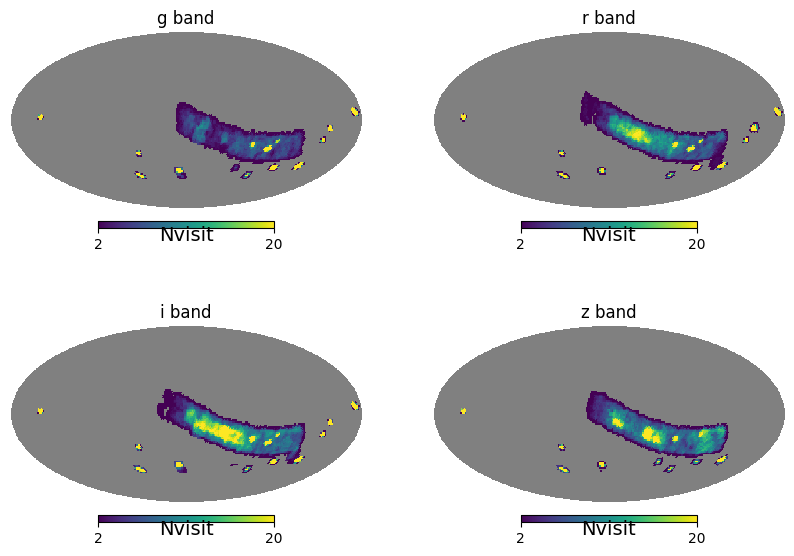

In [31]:
fig,axarr=plt.subplots(2,2,figsize=[10,7])
plt.sca(axarr[0,0])
hp.mollview(nvisits['g'], hold=True, min=2, max=20, title="g band", unit="Nvisit")

plt.sca(axarr[0,1])
hp.mollview(nvisits['r'], hold=True, min=2, max=20, title="r band", unit="Nvisit")

plt.sca(axarr[1,0])
hp.mollview(nvisits['i'], hold=True, min=2, max=20, title="i band", unit="Nvisit")

plt.sca(axarr[1,1])
hp.mollview(nvisits['z'], hold=True, min=2, max=20, title="z band", unit="Nvisit")

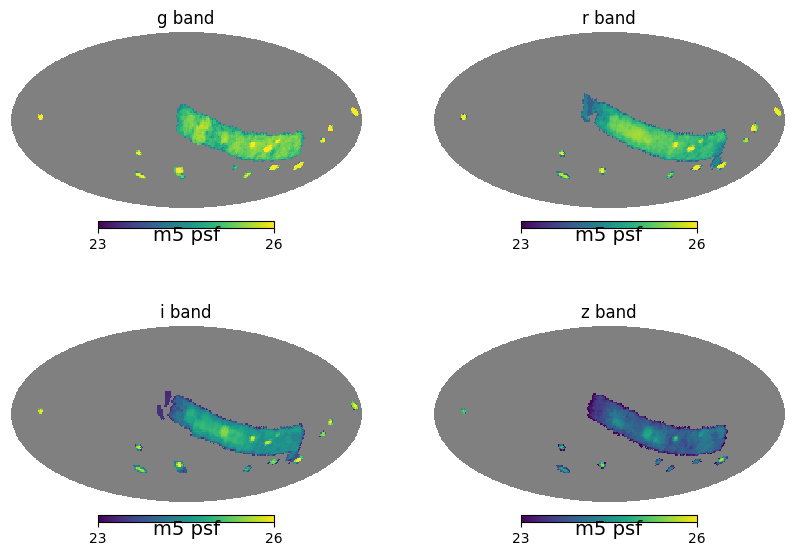

In [36]:
fig,axarr=plt.subplots(2,2,figsize=[10,7])
plt.sca(axarr[0,0])
hp.mollview(depth['g'], hold=True, min=23, max=26, title="g band", unit="m5 psf")

plt.sca(axarr[0,1])
hp.mollview(depth['r'], hold=True, min=23, max=26, title="r band", unit="m5 psf")

plt.sca(axarr[1,0])
hp.mollview(depth['i'], hold=True, min=23, max=26, title="i band", unit="m5 psf")

plt.sca(axarr[1,1])
hp.mollview(depth['z'], hold=True, min=23, max=26, title="z band", unit="m5 psf")

In [140]:
# check DESI samples:
Ngal_desi={}
tracers = ["BGS", "LRG", "ELG_LOP"]
root = "/global/cfs/cdirs/lsst/groups/PZ/Cardinal/parquet_files/dp2_mock_run_cardinal_gold_test/"
for tracer in tracers:
    df = pd.read_parquet(root + f"output_select_lsst_obs_cond_dp2_DESI_{tracer}_color.pq")
    df_pix = hp.ang2pix(256, df['ra'], df['dec'], lonlat=True)
    counts = np.bincount(df_pix, minlength = int(12*256**2))
    Ngal_desi[tracer] = counts

In [44]:
mask_desi = hp.read_map("/pscratch/sd/q/qhang/Flagship/desi-model-mask-nside-256.fits")
boundary_pixels = get_boundary_pixels(mask_desi)
boundary_theta, boundary_phi = hp.pix2ang(256, boundary_pixels, lonlat=True)

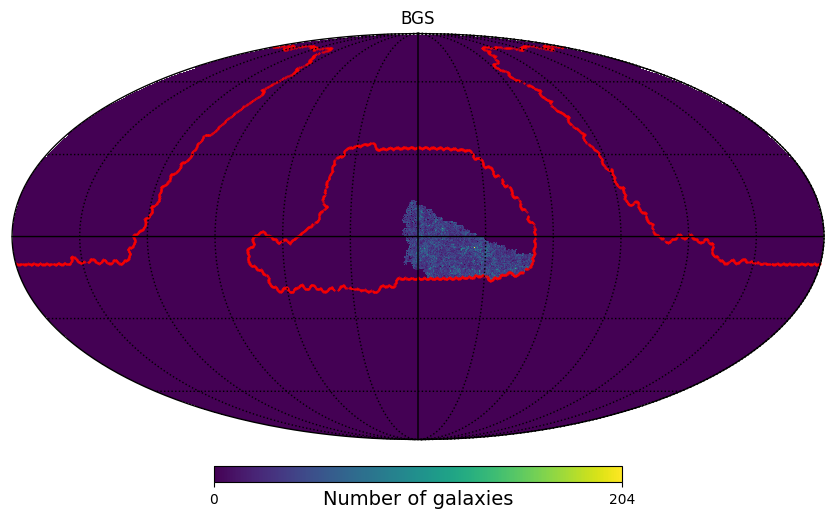

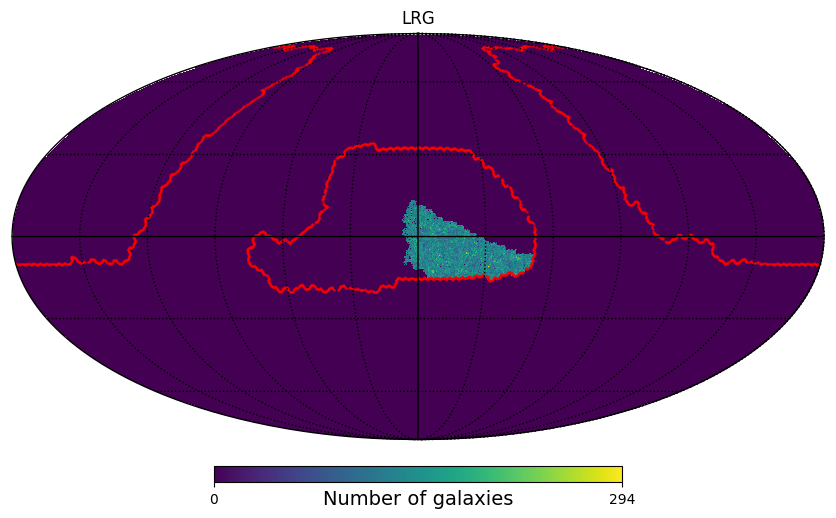

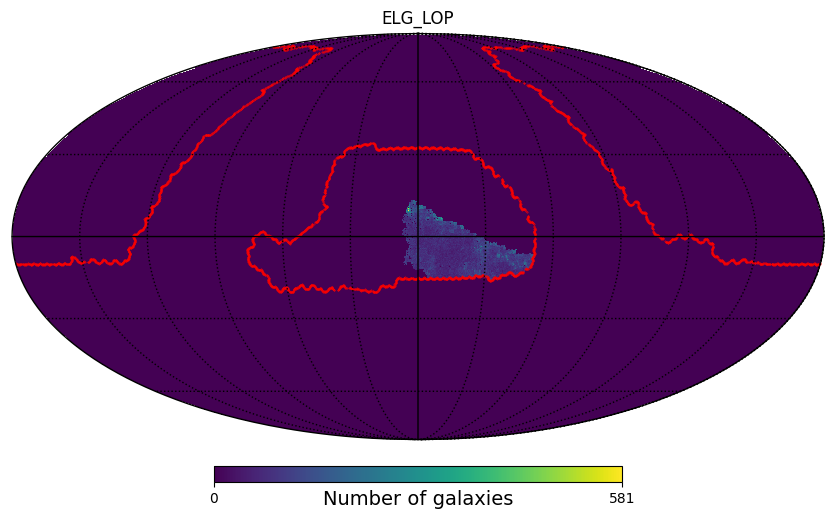

In [142]:
for i, tracer in enumerate(tracers):
    hp.mollview(Ngal_desi[tracer], title=tracer, unit="Number of galaxies")
    hp.projscatter(boundary_theta, boundary_phi, lonlat=True,
               s=0.5, c="red", marker=".", label="master mask")
    hp.graticule()

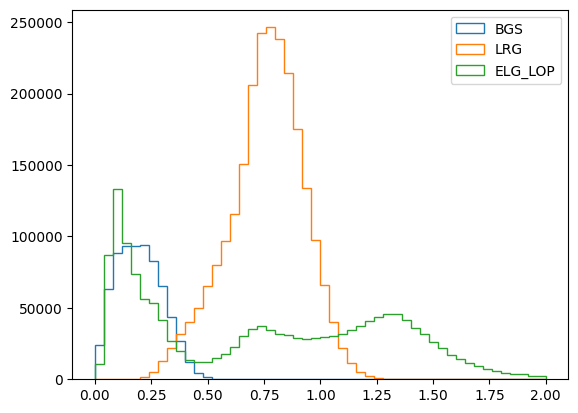

In [143]:
# redshift distribution number density etc.:
for tracer in tracers:
    df = pd.read_parquet(root + f"output_select_lsst_obs_cond_dp2_DESI_{tracer}_color.pq")
    cc = plt.hist(df['redshift'], bins=50, range=[0,2], histtype='step', label=tracer)
plt.legend()